# 6. Streamlit app for classification model

🔹 A. Exploration (historical data) - transparency + insight

Users can:

- Select state
- Select time range  
- View:
    - biodiversity observations
    - anomalies (your target)
    - weather variables

🔹 B. Prediction (model) - real-world application

Users can:

- Input:
    - state
    - month/year (or future scenario)
    - weather conditions (different climate change scenarios)
- Output:
    - probability of biodiversity anomaly
    - classification (shock / no shock)

In [313]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

In [356]:
# Load data
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

# Load model
model_bundle = joblib.load("../models/production_model.pkl")
model = model_bundle['model']

# Get features
features = model_bundle['features']

# Get optimised proba threshold
threshold = model_bundle['threshold']

Define scenarios  

Key Climate Change Scenarios (IPCC 6th Assessment Report):

    SSP1-1.9 (Very Low Emissions): A best-case scenario aiming to keep global warming below
    by 2100 with rapid decarbonization and high global cooperation.  
    SSP1-2.6 (Low Emissions): A scenario where emissions decline after 2050, resulting in intermediate climate goals.  
    SSP2-4.5 (Intermediate Emissions): A "middle-of-the-road" scenario where emissions fluctuate and flatten by mid-century, leading to moderate changes.  
    SSP3-7.0 (High Emissions): A future with low international cooperation, slow technological growth, and high emissions.  
    SSP5-8.5 (Very High Emissions): A worst-case scenario featuring high fossil fuel dependence, leading to rapid temperature increases (by 2100) and severe impacts. 


Temperature Scenarios (2021-2100 Projections)

    Low Emissions (SSP1-1.9/2.6): Aims to keep warming closer to
    to 1.5°C - 2°C
    High Emissions (SSP5-8.5): Temperatures could rise by 3.3°C to 5.7°C, with significant Arctic amplification.
    Regional Variation: Land areas warm faster than oceans, and the Arctic is warming significantly faster than the global average. 

Precipitation Scenarios

    Seasonal Changes: Winters may see up to 20% more rain in some regions, while summers could face up to 25% less, exacerbating water shortages.
    Increased Intensity: Extreme precipitation events are expected to increase in frequency and intensity, causing higher flood risks. 

In [315]:
SCENARIOS = {
    "best case": {
        "temp increase":1.5,
        "precipitation change": 0.1
    },
    "middle of the road": {
        "temp increase":3,
        "precipitation change": 0.2
    },
    "business as usual": {
        "temp increase":5,
        "precipitation change": 0.3
    },
}

Need a slider for:  
    - temp increase (translate degrees C to z-values) (let user choose scenario e.g. 2C warming by 2100, but reduce increase for 10 years)  
    - (with temp increase, also increase likelihood of extreme hot days?)  
    - precipitation change (increase winter rain and decrease summer rain by same amount from baseline)  
    - (with precipitation change also increase frequency of extreme precipitation events)  

Also give preset scenarios based on IPCC projections

Define function to simulate future data

In [316]:
features

['state',
 'year_offset',
 'month_sin',
 'month_cos',
 'n_hot_days_lag1',
 'n_hot_days_roll3',
 'heavy_rain_days_lag1',
 'heavy_rain_days_roll3',
 'temp_anom_z_lag1',
 'temp_anom_z_roll3',
 'precip_anom_z_lag1',
 'precip_anom_z_roll3',
 'drought_index_lag1',
 'drought_index_roll3',
 'log_n_obs']

In [317]:
df = full_df
#scenario = SCENARIOS['best case']
#scenario = SCENARIOS['middle of the road']
scenario = SCENARIOS['business as usual']

# Get historic baseline, mean, std for temp and precip per state and month
# for calculating z scores and anomalies for future data
# note - all on original scale

baseline = df.groupby(['state', 'month']).agg(
    temp_anom_mean = ('temp_anomaly', 'mean'),
    temp_anom_std = ('temp_anomaly', 'std'),
    temp_baseline = ('baseline_temp', 'max'),
    precip_anom_mean = ('precip_prop_anomaly', 'mean'),
    precip_anom_std = ('precip_prop_anomaly', 'std'),
    precip_baseline = ('baseline_precip', 'max')
).reset_index()

# expand baseline df to 10 years 
#future_weather = pd.concat([baseline] * 10, ignore_index=True)
dfs = [baseline.assign(future_year_offset=i) for i in range(1, 11)]
future_weather = pd.concat(dfs, ignore_index=True)

# Set projected temp & precip change by 2100
projected_temp_increase = scenario['temp increase'] #in degrees C
projected_precip_change = scenario['precipitation change'] #proportional change e.g 20% wetter/drier (amplitude in sinusoidal calculation)

# ---------------------------------------
# Simulate future temperature anomalies
#---------------------------------------
# calculate yearly projected temp increase
yearly_temp_increase = projected_temp_increase/(2100-2024)
# calculate future temps with random noise (increasing noise variability over time)
future_weather['simulated_temp'] = (future_weather['temp_baseline'] 
                               + (yearly_temp_increase * future_weather['future_year_offset'])
                               + np.random.normal(0, 0.5 + 0.01 * future_weather['future_year_offset'], 
                                                  size=len(future_weather)))

# calculate z-scores based on baseline data
future_weather['temp_anomaly'] = future_weather['simulated_temp'] - future_weather['temp_baseline']
future_weather['temp_anom_z'] = ((future_weather['temp_anomaly'] - future_weather['temp_anom_mean'])
                                 / future_weather['temp_anom_std'])

# ---------------------------------------
# Simulate future precipitation anomalies
#---------------------------------------
# Define simulation horizon
max_years = future_weather['future_year_offset'].max()

# Seasonal amplitude grows over simulation period
growth = future_weather['future_year_offset'] / max_years

# Seasonal pattern (stronger over time)
future_weather['seasonal_precip'] = (
    projected_precip_change
    * growth
    * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12)
)

# simulate future precipitation with increasing noise variability over time
future_weather['simulated_precip'] = (
    future_weather['precip_baseline']
    * (1 + future_weather['seasonal_precip'])
    * np.exp(np.random.normal(
        0,
        0.15 + 0.01 * future_weather['future_year_offset'],  # slightly reduced base noise
        size=len(future_weather)
    ))
).clip(lower=0)


# note for precipitation, calculate relative anomaly (e.g. 40% wetter/drier than normal)
future_weather['precip_anomaly'] = (
    (future_weather['simulated_precip'] - future_weather['precip_baseline'])
    / future_weather['precip_baseline']
)

future_weather['precip_anom_z'] = (
    (future_weather['precip_anomaly'] - future_weather['precip_anom_mean'])
    / future_weather['precip_anom_std']
)


# note for precipitation, calculate relative anomaly (e.g. 40% wetter/drier than normal)
future_weather['precip_anomaly'] = ((future_weather['simulated_precip'] - future_weather['precip_baseline'])
                                    / future_weather['precip_baseline'])
future_weather['precip_anom_z'] = ((future_weather['precip_anomaly'] - future_weather['precip_anom_mean'])
                                 / future_weather['precip_anom_std'])


# ---------------------------------------
# Simulate future drought risk
#---------------------------------------
# simulate drought index
future_weather['drought_index'] = future_weather['temp_anom_z'] - future_weather['precip_anom_z']

# ---------------------------------------
# Simulate future hot days per month
#---------------------------------------
baseline_hot_days = df.loc[df['year']==2024, ['state', 'month', 'n_hot_days']]
baseline_hot_days = baseline_hot_days.rename(columns={'n_hot_days': 'baseline_hot_days'})
hot_day_sensitivity = 3 # extra hot days per +1°C
future_weather = future_weather.merge(baseline_hot_days)
# Seasonal pattern (more likely to have hot days in summer than winter, increasing in severity with time)
# amplify summer hot days and suppress winter hot days
season_weight = np.clip(
    np.cos(2 * np.pi * (future_weather['month'] - 7) / 12),
    0,
    None
) ** 3 #cube the result to constrain winter values even more while keeping a strong summer signal
# simulte n_hot_days with increasing noise variability over time
future_weather['n_hot_days'] = (
    (
        future_weather['baseline_hot_days']
        + hot_day_sensitivity * (future_weather['temp_anomaly']) #using simulated temp here takes account of long-term trend
    )
    * season_weight
    + np.random.normal(0, 0.3 + 0.01 * future_weather['future_year_offset'], 
                                                  size=len(future_weather))
).clip(0, 31).round()

# ---------------------------------------
# Simulate future heavy rain days per month
#---------------------------------------
baseline_rain_days = df.loc[df['year'] == 2024, ['state', 'month', 'heavy_rain_days']]
baseline_rain_days = baseline_rain_days.rename(columns={'heavy_rain_days': 'baseline_rain_days'})
future_weather = future_weather.merge(baseline_rain_days, on=['state', 'month'], how='left')
rain_season_weight = (
    # 0.5 + 0.5 * cos -> rescales cosine from [-1, 1] to [0, 1]
    0.5 + 0.5 * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12)
) ** 2

rain_sensitivity = 12  # higher for more extreme effects - wetter winters, drier summers
noise = np.random.normal(
    0,
    0.1 * (0.5 + rain_season_weight),  # more variability in wetter months
    len(future_weather)
)

future_weather['heavy_rain_days'] = (
    future_weather['baseline_rain_days']
    + rain_sensitivity * future_weather['precip_anomaly'] * rain_season_weight
    + noise
).clip(0, 31).round()


future_weather

,state,month,temp_anom_mean,temp_anom_std,temp_baseline,precip_anom_mean,precip_anom_std,precip_baseline,future_year_offset,simulated_temp,...,temp_anom_z,seasonal_precip,simulated_precip,precip_anomaly,precip_anom_z,drought_index,baseline_hot_days,n_hot_days,baseline_rain_days,heavy_rain_days
0,Baden-Württemberg,1,-3.122148e-08,2.331786,0.888582,-3.405980e-08,0.491852,73.585716,1,0.514021,...,-0.160632,3.000000e-02,76.436415,0.038740,0.078763,-0.239396,0,0.0,1,2.0
1,Baden-Württemberg,2,4.541306e-08,3.051575,1.658827,-3.831727e-08,0.555854,58.023811,1,1.317211,...,-0.111947,2.598076e-02,51.319614,-0.115542,-0.207864,0.095917,0,0.0,1,0.0
2,Baden-Württemberg,3,1.702990e-07,1.838980,4.780743,-4.927140e-08,0.459564,60.757145,1,4.605996,...,-0.095024,1.500000e-02,48.594538,-0.200184,-0.435595,0.340571,0,0.0,2,1.0
3,Baden-Württemberg,4,-3.405980e-07,1.795552,9.264582,1.277242e-08,0.520652,61.628571,1,9.883664,...,0.344787,1.836970e-18,44.969769,-0.270310,-0.519175,0.863962,0,0.0,2,1.0
4,Baden-Württemberg,5,6.357829e-07,1.590371,13.113695,2.270653e-08,0.388631,91.942856,1,13.081534,...,-0.020223,-1.500000e-02,93.486006,0.016784,0.043187,-0.063410,0,0.0,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,Thüringen,8,-1.365492e-01,1.626049,18.361685,3.601326e-02,0.509199,84.522728,10,18.981164,...,0.464948,-2.598076e-01,75.593486,-0.105643,-0.278195,0.743143,2,3.0,2,2.0
1916,Thüringen,9,1.804256e-02,1.605054,14.538055,6.099200e-03,0.441564,62.849998,10,14.761634,...,0.128056,-1.500000e-01,41.820380,-0.334600,-0.771574,0.899629,1,0.0,2,2.0
1917,Thüringen,10,1.823114e-01,1.515943,10.015421,2.924070e-03,0.401003,59.663635,10,10.500689,...,0.199847,-5.510911e-17,90.331052,0.514005,1.274506,-1.074659,0,1.0,1,2.0
1918,Thüringen,11,-4.058743e-02,1.205193,5.154050,1.316289e-02,0.553142,56.386364,10,5.620757,...,0.420924,1.500000e-01,65.846168,0.167768,0.279503,0.141421,0,0.0,1,2.0


Sense check plots for simulated features

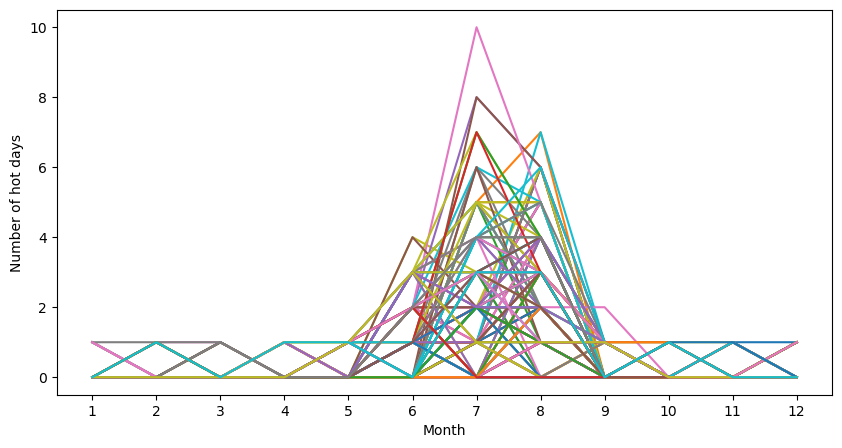

In [318]:
#plot simulated n_hot_days per month
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for state in future_weather['state'].unique():
    for i in range(1, 11):
        subset = future_weather[
            (future_weather['state'] == state) &
            (future_weather['future_year_offset'] == i)
        ]

        plt.plot(
            subset['month'],
            subset['n_hot_days'],
            label=f'{state} year {i}',
            linewidth=1.5
        )

plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Number of hot days')
#plt.legend()
plt.show()

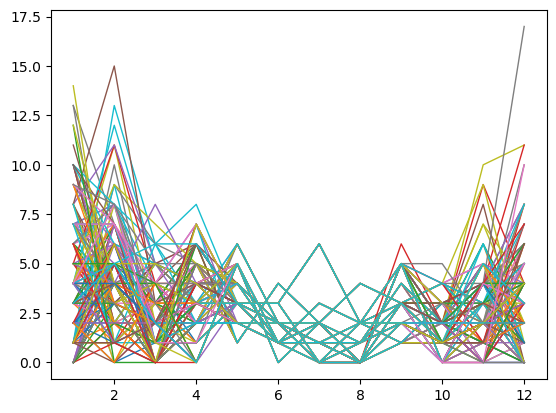

In [319]:
#plot simulated heavy_rain_days per month
import matplotlib.pyplot as plt

for state in future_weather['state'].unique():
    for i in range(1, 11):
        subset = future_weather[
            (future_weather['state'] == state) &
            (future_weather['future_year_offset'] == i)
        ]
        
        plt.plot(
            subset['month'],
            subset['heavy_rain_days'],
            label=f'{state} year {i}',
            linewidth=1
        )

#plt.legend()
plt.show()

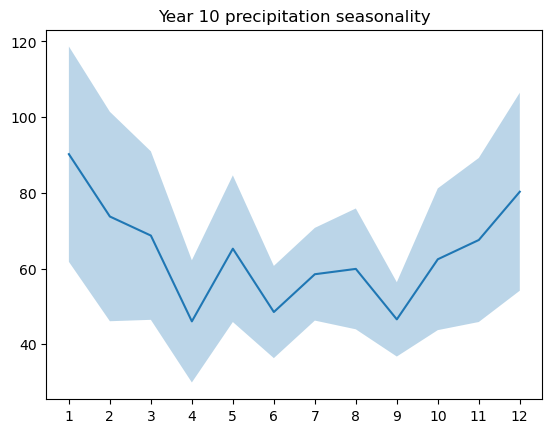

In [320]:
%matplotlib inline

year_data = future_weather[future_weather['future_year_offset'] == 10]

agg = year_data.groupby('month')['simulated_precip'].agg(['mean','std']).reset_index()

plt.plot(agg['month'], agg['mean'])
plt.fill_between(
    agg['month'],
    agg['mean'] - agg['std'],
    agg['mean'] + agg['std'],
    alpha=0.3
)

plt.xticks(range(1,13))
plt.title('Year 10 precipitation seasonality')
plt.show()

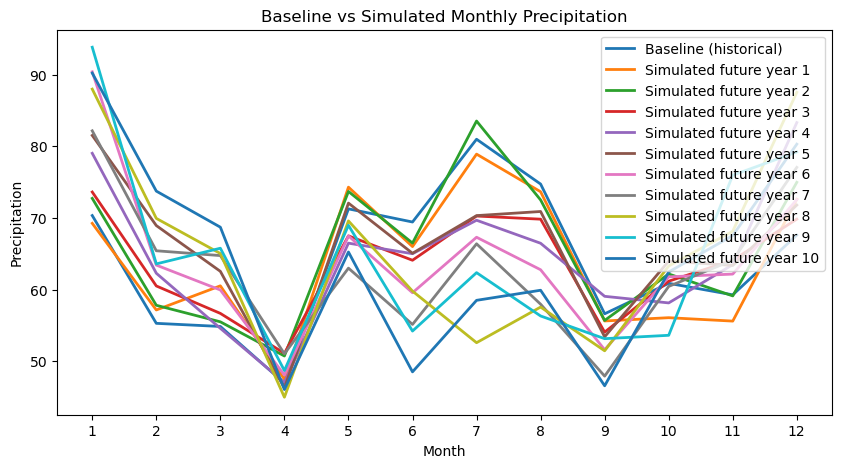

In [321]:
baseline_monthly = baseline.groupby('month')['precip_baseline'].mean().reset_index()
sim_monthly = future_weather.groupby(['future_year_offset', 'month'])['simulated_precip'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Baseline
plt.plot(
    baseline_monthly['month'],
    baseline_monthly['precip_baseline'],
    label='Baseline (historical)',
    linewidth=2
)

for i in range(1, 11):
    # Simulated
    plt.plot(
        sim_monthly.loc[sim_monthly['future_year_offset']==i, 'month'],
        sim_monthly.loc[sim_monthly['future_year_offset']==i, 'simulated_precip'],
        label=f'Simulated future year {i}',
        linewidth=2
    )

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Precipitation')
plt.title('Baseline vs Simulated Monthly Precipitation')
plt.legend()
plt.show()

Because the model uses lagged and rolling average features, add future weather data to historic data (only 3 months from 10/2024 to 12/2024 needed) and calculate lag1 and roll3 features

In [ ]:
#get last 3 months of 2024
latest_weather = full_df.loc[(full_df['year']==2024) & (full_df['month']>9)]

#drop columns not needed for model
#latest_weather = latest_weather[features]
#latest_weather

#concat future weather
future_weather['year'] = 2024 + future_weather['future_year_offset']
future_weather['year_offset'] = 20 + future_weather['future_year_offset']
future_weather['month_sin'] = np.sin(2*np.pi * future_weather['month'] / 12)
future_weather['month_cos'] = np.cos(2*np.pi * future_weather['month'] / 12)
#add log_n_obs as mean of last 3 years per month per state
recent = df[df['year'] >= df['year'].max() - 3]
baseline_log_n_obs = (recent.groupby(['state', 'month'])['log_n_obs']
                      .mean()
                      .reindex(future_weather.set_index(['state', 'month']).index)
                      .values)
future_weather['log_n_obs'] = (baseline_log_n_obs)
future_weather = pd.concat([latest_weather, future_weather])

future_weather = future_weather.sort_values(['state', 'year', 'month'])

#calculate lagged features
future_weather['temp_anom_z_lag1'] = future_weather.groupby('state')['temp_anom_z'].shift(1)
future_weather['precip_anom_z_lag1'] = future_weather.groupby('state')['precip_anom_z'].shift(1)
future_weather['n_hot_days_lag1'] = future_weather.groupby('state')['n_hot_days'].shift(1)
future_weather['drought_index_lag1'] = future_weather.groupby('state')['drought_index'].shift(1)
future_weather['heavy_rain_days_lag1'] = future_weather.groupby('state')['heavy_rain_days'].shift(1)


#calculate rolling features
# 3 month rolling mean (shift back one month to avoid including current month in mean)
future_weather['temp_anom_z_roll3'] = future_weather.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
future_weather['precip_anom_z_roll3'] = future_weather.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
future_weather['n_hot_days_roll3'] = future_weather.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
future_weather['drought_index_roll3'] = future_weather.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
future_weather['heavy_rain_days_roll3'] = future_weather.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

future_weather = future_weather[features]
future_weather[future_weather['state']=='Berlin']

#Remove rows from 2024 (year_offset == 20)
future_weather = future_weather.loc[future_weather['year_offset']>20]
future_weather[future_weather['state']=='Berlin']
                                     

,state,year_offset,month_sin,month_cos,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days_lag1,heavy_rain_days_roll3,temp_anom_z_lag1,temp_anom_z_roll3,precip_anom_z_lag1,precip_anom_z_roll3,drought_index_lag1,drought_index_roll3,log_n_obs
24,Berlin,21,5.000000e-01,8.660254e-01,0.0,0.000000,1.0,2.000000,0.470346,0.179036,-0.552874,-0.027137,1.023220,0.206173,3.819140
25,Berlin,21,8.660254e-01,5.000000e-01,0.0,0.000000,0.0,1.333333,0.238640,0.086347,-0.177433,-0.071466,0.416073,0.157813,3.797451
26,Berlin,21,1.000000e+00,6.123234e-17,0.0,0.000000,4.0,1.666667,-0.033374,0.225204,0.027624,-0.234228,-0.060997,0.459432,3.974181
27,Berlin,21,8.660254e-01,-5.000000e-01,0.0,0.000000,0.0,1.333333,-0.128073,0.025731,-0.285959,-0.145256,0.157885,0.170987,4.062159
28,Berlin,21,5.000000e-01,-8.660254e-01,0.0,0.000000,2.0,2.000000,0.111988,-0.016486,0.289126,0.010264,-0.177138,-0.026750,4.182251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,Berlin,30,-8.660254e-01,-5.000000e-01,6.0,2.666667,1.0,3.000000,0.626846,0.446191,-0.628873,-0.559826,1.255718,1.006016,3.835937
1760,Berlin,30,-1.000000e+00,-1.836970e-16,5.0,4.333333,0.0,1.000000,0.296197,0.497937,-0.314906,-0.612259,0.611103,1.110196,3.809713
1761,Berlin,30,-8.660254e-01,5.000000e-01,0.0,3.666667,1.0,0.666667,0.317056,0.413366,0.087771,-0.285336,0.229284,0.698702,3.772302
1762,Berlin,30,-5.000000e-01,8.660254e-01,0.0,1.666667,2.0,1.000000,0.352501,0.321918,0.011018,-0.072039,0.341483,0.393956,3.642622


Now we have a dataset to use with the model for forecasting! 

Turn this logic into a function:

In [349]:
df = full_df
#scenario = SCENARIOS['best case']
#scenario = SCENARIOS['middle of the road']
scenario = SCENARIOS['business as usual']

def simulate_future(df, features, scenario):
    
    """
    Parameters
    ----------
    df : pandas DataFrame
        the full historic dataframe on which the model was trained
    features : list
        a list of the feature names that were used to train the model
    scenario : str
        Climate change scenarios based on IPCC projections by year 2100
        SCENARIOS = {
            "best case": {
                "temp increase":1.5,
                "precipitation change": 0.1
            },
            "middle of the road": {
                "temp increase":3,
                "precipitation change": 0.2
            },
            "business as usual": {
                "temp increase":5,
                "precipitation change": 0.3
            },
        }
    """

    # Get historic baseline, mean, std for temp and precip per state and month
    # for calculating z scores and anomalies for future data
    # note - all on original scale

    baseline = df.groupby(['state', 'month']).agg(
        temp_anom_mean = ('temp_anomaly', 'mean'),
        temp_anom_std = ('temp_anomaly', 'std'),
        temp_baseline = ('baseline_temp', 'max'),
        precip_anom_mean = ('precip_prop_anomaly', 'mean'),
        precip_anom_std = ('precip_prop_anomaly', 'std'),
        precip_baseline = ('baseline_precip', 'max')
    ).reset_index()

    # expand baseline df to 10 years 
    #future_weather = pd.concat([baseline] * 10, ignore_index=True)
    dfs = [baseline.assign(future_year_offset=i) for i in range(1, 11)]
    future_weather = pd.concat(dfs, ignore_index=True)

    # Set projected temp & precip change by 2100
    projected_temp_increase = scenario['temp increase'] #in degrees C
    projected_precip_change = scenario['precipitation change'] #proportional change e.g 20% wetter/drier (amplitude in sinusoidal calculation)

    # ---------------------------------------
    # Simulate future temperature anomalies
    #---------------------------------------
    # calculate yearly projected temp increase
    yearly_temp_increase = projected_temp_increase/(2100-2024)
    # calculate future temps with random noise (increasing noise variability over time)
    future_weather['simulated_temp'] = (future_weather['temp_baseline'] 
                                + (yearly_temp_increase * future_weather['future_year_offset'])
                                + np.random.normal(0, 0.5 + 0.01 * future_weather['future_year_offset'], 
                                                    size=len(future_weather)))

    # calculate z-scores based on baseline data
    future_weather['temp_anomaly'] = future_weather['simulated_temp'] - future_weather['temp_baseline']
    future_weather['temp_anom_z'] = ((future_weather['temp_anomaly'] - future_weather['temp_anom_mean'])
                                    / future_weather['temp_anom_std'])

    # ---------------------------------------
    # Simulate future precipitation anomalies
    #---------------------------------------
    # Define simulation horizon
    max_years = future_weather['future_year_offset'].max()

    # Seasonal amplitude grows over simulation period
    growth = future_weather['future_year_offset'] / max_years

    # Seasonal pattern (stronger over time)
    future_weather['seasonal_precip'] = (
        projected_precip_change
        * growth
        * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12)
    )

    # simulate future precipitation with increasing noise variability over time
    future_weather['simulated_precip'] = (
        future_weather['precip_baseline']
        * (1 + future_weather['seasonal_precip'])
        * np.exp(np.random.normal(
            0,
            0.15 + 0.01 * future_weather['future_year_offset'],  # slightly reduced base noise
            size=len(future_weather)
        ))
    ).clip(lower=0)


    # note for precipitation, calculate relative anomaly (e.g. 40% wetter/drier than normal)
    future_weather['precip_anomaly'] = (
        (future_weather['simulated_precip'] - future_weather['precip_baseline'])
        / future_weather['precip_baseline']
    )

    future_weather['precip_anom_z'] = (
        (future_weather['precip_anomaly'] - future_weather['precip_anom_mean'])
        / future_weather['precip_anom_std']
    )


    # note for precipitation, calculate relative anomaly (e.g. 40% wetter/drier than normal)
    future_weather['precip_anomaly'] = ((future_weather['simulated_precip'] - future_weather['precip_baseline'])
                                        / future_weather['precip_baseline'])
    future_weather['precip_anom_z'] = ((future_weather['precip_anomaly'] - future_weather['precip_anom_mean'])
                                    / future_weather['precip_anom_std'])


    # ---------------------------------------
    # Simulate future drought risk
    #---------------------------------------
    # simulate drought index
    future_weather['drought_index'] = future_weather['temp_anom_z'] - future_weather['precip_anom_z']

    # ---------------------------------------
    # Simulate future hot days per month
    #---------------------------------------
    baseline_hot_days = df.loc[df['year']==2024, ['state', 'month', 'n_hot_days']]
    baseline_hot_days = baseline_hot_days.rename(columns={'n_hot_days': 'baseline_hot_days'})
    hot_day_sensitivity = 3 # extra hot days per +1°C
    future_weather = future_weather.merge(baseline_hot_days)
    # Seasonal pattern (more likely to have hot days in summer than winter, increasing in severity with time)
    # amplify summer hot days and suppress winter hot days
    season_weight = np.clip(
        np.cos(2 * np.pi * (future_weather['month'] - 7) / 12),
        0,
        None
    ) ** 3 #cube the result to constrain winter values even more while keeping a strong summer signal
    # simulte n_hot_days with increasing noise variability over time
    future_weather['n_hot_days'] = (
        (
            future_weather['baseline_hot_days']
            + hot_day_sensitivity * (future_weather['temp_anomaly']) #using simulated temp here takes account of long-term trend
        )
        * season_weight
        + np.random.normal(0, 0.3 + 0.01 * future_weather['future_year_offset'], 
                                                    size=len(future_weather))
    ).clip(0, 31).round()

    # ---------------------------------------
    # Simulate future heavy rain days per month
    #---------------------------------------
    baseline_rain_days = df.loc[df['year'] == 2024, ['state', 'month', 'heavy_rain_days']]
    baseline_rain_days = baseline_rain_days.rename(columns={'heavy_rain_days': 'baseline_rain_days'})
    future_weather = future_weather.merge(baseline_rain_days, on=['state', 'month'], how='left')
    rain_season_weight = (
        # 0.5 + 0.5 * cos -> rescales cosine from [-1, 1] to [0, 1]
        0.5 + 0.5 * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12)
    ) ** 2

    rain_sensitivity = 12  # higher for more extreme effects - wetter winters, drier summers
    noise = np.random.normal(
        0,
        0.1 * (0.5 + rain_season_weight),  # more variability in wetter months
        len(future_weather)
    )

    future_weather['heavy_rain_days'] = (
        future_weather['baseline_rain_days']
        + rain_sensitivity * future_weather['precip_anomaly'] * rain_season_weight
        + noise
    ).clip(0, 31).round()

    #-----------------------------------------
    # Calculate lagged features, cyclical months and log_n_obs
    #-----------------------------------------
    #get last 3 months of 2024
    latest_weather = full_df.loc[(full_df['year']==2024) & (full_df['month']>9)]

    #drop columns not needed for model
    #latest_weather = latest_weather[features]
    #latest_weather

    #concat future weather
    future_weather['year'] = 2024 + future_weather['future_year_offset']
    future_weather['year_offset'] = 20 + future_weather['future_year_offset']
    future_weather['month_sin'] = np.sin(2*np.pi * future_weather['month'] / 12)
    future_weather['month_cos'] = np.cos(2*np.pi * future_weather['month'] / 12)
    #add log_n_obs as mean of last 3 years per month per state
    recent = df[df['year'] >= df['year'].max() - 3]
    baseline_log_n_obs = (recent.groupby(['state', 'month'])['log_n_obs']
                        .mean()
                        .reindex(future_weather.set_index(['state', 'month']).index)
                        .values)
    future_weather['log_n_obs'] = (baseline_log_n_obs)
    future_weather = pd.concat([latest_weather, future_weather])

    future_weather = future_weather.sort_values(['state', 'year', 'month'])

    #calculate lagged features
    future_weather['temp_anom_z_lag1'] = future_weather.groupby('state')['temp_anom_z'].shift(1)
    future_weather['precip_anom_z_lag1'] = future_weather.groupby('state')['precip_anom_z'].shift(1)
    future_weather['n_hot_days_lag1'] = future_weather.groupby('state')['n_hot_days'].shift(1)
    future_weather['drought_index_lag1'] = future_weather.groupby('state')['drought_index'].shift(1)
    future_weather['heavy_rain_days_lag1'] = future_weather.groupby('state')['heavy_rain_days'].shift(1)


    #calculate rolling features
    # 3 month rolling mean (shift back one month to avoid including current month in mean)
    future_weather['temp_anom_z_roll3'] = future_weather.groupby('state')['temp_anom_z'].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    future_weather['precip_anom_z_roll3'] = future_weather.groupby('state')['precip_anom_z'].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    future_weather['n_hot_days_roll3'] = future_weather.groupby('state')['n_hot_days'].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    future_weather['drought_index_roll3'] = future_weather.groupby('state')['drought_index'].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    future_weather['heavy_rain_days_roll3'] = future_weather.groupby('state')['heavy_rain_days'].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

    #keep year and month in df for later reporting
    features.extend(['year', 'month'])

    future_weather = future_weather[features]

    #Remove rows from 2024 (year_offset == 20)
    future_weather = future_weather.loc[future_weather['year_offset']>20]
                                     


    return future_weather

Now define function to apply the model to the future weather data and return the number of predicted biodiversity anomalies per month/year/Bundesland

In [374]:
def forecast_bioshocks(df, model, features, threshold):
    """
    Apply the model to the future weather data simulated with simulate_future() to predict biodiversity anomalies
    Return df with model predictions as proba values and presence/absence biodiversity_anomaly based on proba threshold

    Parameters
    ----------
    df : pandas DataFrame
        the simulated future weather dataframe returned by simulate_future()
    model : the trained model
    features : list
        a list of the feature names that were used to train the model
    threshold : float
        the optimised threshold for proba values (saved in the trained model bundle)
    
    """

    # Dataframe with only necessary features
    X = df[features]

    # Predict probability
    proba = model.predict_proba(X)[:, 1]

    #add predictions to df
    df['proba'] = proba
    df['biodiversity_anomaly'] = (df['proba'] >= threshold).astype(int)

    return df


In [378]:
# Test functions
scenario = SCENARIOS['business as usual']
X = simulate_future(df = full_df, features = features, scenario = scenario)

In [379]:
X = forecast_bioshocks(df = X, model = model, features = features, threshold=threshold)

In [380]:
X

,state,year_offset,month_sin,month_cos,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days_lag1,heavy_rain_days_roll3,temp_anom_z_lag1,temp_anom_z_roll3,...,year,month,year,month,year,month,year,month,proba,biodiversity_anomaly
0,Baden-Württemberg,21,5.000000e-01,8.660254e-01,0.0,0.000000,2.0,1.666667,0.103112,0.309404,...,2025,1,2025,1,2025,1,2025,1,0.301203,1
1,Baden-Württemberg,21,8.660254e-01,5.000000e-01,1.0,0.333333,4.0,2.666667,-0.170491,-0.001167,...,2025,2,2025,2,2025,2,2025,2,0.038101,0
2,Baden-Württemberg,21,1.000000e+00,6.123234e-17,0.0,0.333333,0.0,2.000000,0.011617,-0.018587,...,2025,3,2025,3,2025,3,2025,3,0.004850,0
3,Baden-Württemberg,21,8.660254e-01,-5.000000e-01,0.0,0.333333,2.0,2.000000,0.115231,-0.014548,...,2025,4,2025,4,2025,4,2025,4,0.000469,0
4,Baden-Württemberg,21,5.000000e-01,-8.660254e-01,0.0,0.000000,2.0,1.333333,0.412960,0.179936,...,2025,5,2025,5,2025,5,2025,5,0.000063,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,Thüringen,30,-8.660254e-01,-5.000000e-01,5.0,2.333333,3.0,3.000000,1.300775,0.824906,...,2034,8,2034,8,2034,8,2034,8,0.026336,0
1916,Thüringen,30,-1.000000e+00,-1.836970e-16,5.0,3.666667,2.0,2.000000,1.554847,1.106496,...,2034,9,2034,9,2034,9,2034,9,0.089850,0
1917,Thüringen,30,-8.660254e-01,5.000000e-01,0.0,3.333333,2.0,2.333333,0.176329,1.010650,...,2034,10,2034,10,2034,10,2034,10,0.640067,1
1918,Thüringen,30,-5.000000e-01,8.660254e-01,0.0,1.666667,2.0,2.000000,0.119363,0.616846,...,2034,11,2034,11,2034,11,2034,11,0.980620,1
